In [2]:
import numpy as np
import pandas as pd

# Step 1: Load and Inspect Data
A loan prediction model helps banks decide if a person should get a loan based on their personal and financial details.

In [3]:
# importing training set

train_perf = pd.read_csv('../data/data-science-nigeria-credit-risk-prediction/trainperf.csv')
train_demo = pd.read_csv('../data/data-science-nigeria-credit-risk-prediction/traindemographics.csv')
train_prev = pd.read_csv('../data/data-science-nigeria-credit-risk-prediction/trainprevloans.csv')

print(f'train_perf shape: {train_perf.shape}' )
print(f'train_perf Columns:\n {train_perf.columns}|\n' )
print(f'train_demo shape: {train_demo.shape}')
print(f'train_demo Columns:\n {train_demo.columns}\n')
print(f'train_prev shape: {train_prev.shape}')
print(f'train_prev Columns:\n {train_prev.columns}')

train_perf shape: (4368, 10)
train_perf Columns:
 Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag'],
      dtype='object')|

train_demo shape: (4346, 9)
train_demo Columns:
 Index(['customerid', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'bank_branch_clients',
       'employment_status_clients', 'level_of_education_clients'],
      dtype='object')

train_prev shape: (18183, 12)
train_prev Columns:
 Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate',
       'referredby', 'firstduedate', 'firstrepaiddate'],
      dtype='object')


#### 1. train_perf (4,368 rows, 10 columns)
"Current loan performance data containing the target variable (good_bad_flag) with loan details including :"
- customerid	Unique identifier for each customer
- systemloanid	Unique identifier for the current loan
- loannumber	Loan reference number
- approveddate	Date the current loan was approved
- creationdate	Date the loan application was created
- loanamount	Amount of money borrowed (current loan)
- totaldue	Total repayment amount (loan + interest + fees)
- termdays	Repayment period in days for current loan
- referredby	Customer ID of the person who referred this customer
- good_bad_flag	TARGET: 'Good' = repaid on time, 'Bad' = defaulted

#### 2. train_demo (4,346 rows, 9 columns)
"Customer demographic and location data with personal details including birthdate, bank info, GPS coordinates, employment, and education."

- customerid	Unique identifier for each customer
- birthdate	Customer's date of birth
- bank_account_type	Type of bank account (Savings, Current, Other)
- longitude_gps	GPS longitude coordinate of customer's location
- latitude_gps	GPS latitude coordinate of customer's location
- bank_name_clients	Name of the customer's bank
- bank_branch_clients	Bank branch location (often missing)
- employment_status_clients	Employment type (Permanent, Self-Employed, etc.)
- level_of_education_clients	Highest education level (Primary, Secondary, Tertiary)

#### 3. train_prev (18,183 rows, 12 columns)
"Historical previous loan data containing all past loans taken by customers with details on amounts, terms, closure dates, and payment history."
- customerid	Unique identifier for each customer
- systemloanid	Unique identifier for each previous loan
- loannumber	Reference number for previous loan
- approveddate	Date previous loan was approved
- creationdate	Date previous loan application was created
- loanamount	Amount borrowed in previous loan
- totaldue	Total repayment amount (loan + interest + fees) for previous loan
- termdays	Repayment period in days for previous loan
- closeddate	Date previous loan was fully repaid/closed
- referredby	Customer ID of who referred customer for previous loan
- firstduedate	Date of first payment due (for multi-payment loans)
- firstrepaiddate	Actual date customer made their first payment

In [4]:
#Find the common columns
common_cols = set(train_perf.columns) & set(train_demo.columns) & set(train_prev.columns)
print(f"\nCommon columns across all 3 files: {common_cols}")


Common columns across all 3 files: {'customerid'}


In [5]:
# Merge on customerid
df = train_perf.merge(train_demo, on='customerid', how = 'left').merge(train_prev, on='customerid', how = 'left')
print(df.shape) # columns = 29  cuz 10+9+12 = 31 - 2 (customerid from 2 columns) 


df.to_csv('../data/merge_df.csv', index = False)
print('merged_df.csv saved')

(18212, 29)
merged_df.csv saved


before applying how = 'left' i had (13693, 29) after applying it i have(18212, 29)
- how = 'left'
Keeps all records from your main dataset (train_perf), even if those customers are completely missing from the demographics (train_demo) or previous loans (train_prev) tables.Fills in missing information with NaN (null) values for any customer who does not exist in the secondary datasets.

- but Before (inner join): i only kept records where a customerid matched across all three tables perfectly, filtering out duplicate mismatches.


# 2. Missing values and Duplicates Audit

In [92]:
df = pd.read_csv('../data/merge_df.csv')
df.columns


Index(['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x',
       'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x',
       'referredby_x', 'good_bad_flag', 'birthdate', 'bank_account_type',
       'longitude_gps', 'latitude_gps', 'bank_name_clients',
       'bank_branch_clients', 'employment_status_clients',
       'level_of_education_clients', 'systemloanid_y', 'loannumber_y',
       'approveddate_y', 'creationdate_y', 'loanamount_y', 'totaldue_y',
       'termdays_y', 'closeddate', 'referredby_y', 'firstduedate',
       'firstrepaiddate'],
      dtype='object')

In [93]:
#target column = good_bad_flag
print(f"\nTarget distribution:")
print(df['good_bad_flag'].value_counts())
print(f"\nPercentage:")
print(df['good_bad_flag'].value_counts(normalize=True) * 100)
print(df['good_bad_flag'].unique())
print(df['good_bad_flag'].nunique())
df.dtypes



Target distribution:
good_bad_flag
Good    14840
Bad      3372
Name: count, dtype: int64

Percentage:
good_bad_flag
Good    81.484735
Bad     18.515265
Name: proportion, dtype: float64
['Good' 'Bad']
2


customerid                     object
systemloanid_x                  int64
loannumber_x                    int64
approveddate_x                 object
creationdate_x                 object
loanamount_x                  float64
totaldue_x                    float64
termdays_x                      int64
referredby_x                   object
good_bad_flag                  object
birthdate                      object
bank_account_type              object
longitude_gps                 float64
latitude_gps                  float64
bank_name_clients              object
bank_branch_clients            object
employment_status_clients      object
level_of_education_clients     object
systemloanid_y                float64
loannumber_y                  float64
approveddate_y                 object
creationdate_y                 object
loanamount_y                  float64
totaldue_y                    float64
termdays_y                    float64
closeddate                     object
referredby_y

In [94]:
# missing values 
miss = df.isnull().sum()
missing_pct = miss * 100 / len(df)
report = pd.DataFrame({
    'missing data': miss,
    'missing_pct': missing_pct
}).sort_values(by = 'missing_pct', ascending = False)
print(f'Missing data: \n {report}\n')

Missing data: 
                             missing data  missing_pct
bank_branch_clients                18105    99.412475
referredby_y                       17184    94.355370
referredby_x                       17184    94.355370
level_of_education_clients         14745    80.963101
employment_status_clients           5877    32.269932
birthdate                           4514    24.785855
latitude_gps                        4514    24.785855
longitude_gps                       4514    24.785855
bank_account_type                   4514    24.785855
bank_name_clients                   4514    24.785855
loannumber_y                           9     0.049418
loanamount_y                           9     0.049418
totaldue_y                             9     0.049418
termdays_y                             9     0.049418
approveddate_y                         9     0.049418
closeddate                             9     0.049418
firstduedate                           9     0.049418
creationdate

In [95]:
# Drop columns with >60% missing
df = df.drop(columns=['bank_branch_clients', 'level_of_education_clients', 'referredby_y', 'referredby_x'], errors='ignore')
print('success')

success


In [97]:
# 1. Fill categorical columns with Mode
cat_cols = ['employment_status_clients', 'bank_account_type', 'bank_name_clients', 'birthdate', 'creationdate_y', 'firstduedate', 'firstrepaiddate', 'closeddate', 'approveddate_y',]
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Fill numeric and date columns with Median
num_cols = ['latitude_gps', 'longitude_gps', 'loannumber_y', 'systemloanid_y', 'termdays_y', 'totaldue_y', 'loanamount_y']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
print('success')

success


In [11]:
#1 duplicate check
duplicate_count = df.duplicated().sum()
print(duplicate_count)

20


In [12]:
# 2. Remove the duplicate rows (keeping the first occurrence)
df = df.drop_duplicates()

# 3. Verify that duplicates are gone
print(df.duplicated().sum())

0


In [13]:
#update merge_df
df.to_csv('../data/updated_merge_df.csv', index = False)
print('success')

success


# 3 EDA (Exploratory Data Analysis)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load merged dataset
df = pd.read_csv('../data/updated_merge_df.csv')  # or your merged file

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

DATASET OVERVIEW
Shape: (18192, 25)

Columns: ['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x', 'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x', 'good_bad_flag', 'birthdate', 'bank_account_type', 'longitude_gps', 'latitude_gps', 'bank_name_clients', 'employment_status_clients', 'systemloanid_y', 'loannumber_y', 'approveddate_y', 'creationdate_y', 'loanamount_y', 'totaldue_y', 'termdays_y', 'closeddate', 'firstduedate', 'firstrepaiddate']

Data Types:
customerid                    object
systemloanid_x                 int64
loannumber_x                   int64
approveddate_x                object
creationdate_x                object
loanamount_x                 float64
totaldue_x                   float64
termdays_x                     int64
good_bad_flag                 object
birthdate                     object
bank_account_type             object
longitude_gps                float64
latitude_gps                 float64
bank_name_clients             obje

### 3.1 Univariate Analysis 


In [15]:
# 1. Automatically get all categorical (text/object) columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Automatically get all numerical (integer/float) columns
num_cols = df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()

# 3. Print the results to verify
print(f"Categorical Columns : ({len(cat_cols)}):\n {cat_cols} \n")
print(f"Numerical Columns: ({len(num_cols)}): \n {num_cols}")


Categorical Columns : (13):
 ['customerid', 'approveddate_x', 'creationdate_x', 'good_bad_flag', 'birthdate', 'bank_account_type', 'bank_name_clients', 'employment_status_clients', 'approveddate_y', 'creationdate_y', 'closeddate', 'firstduedate', 'firstrepaiddate'] 

Numerical Columns: (12): 
 ['systemloanid_x', 'loannumber_x', 'loanamount_x', 'totaldue_x', 'termdays_x', 'longitude_gps', 'latitude_gps', 'systemloanid_y', 'loannumber_y', 'loanamount_y', 'totaldue_y', 'termdays_y']



### Univariate analyses of num_cols

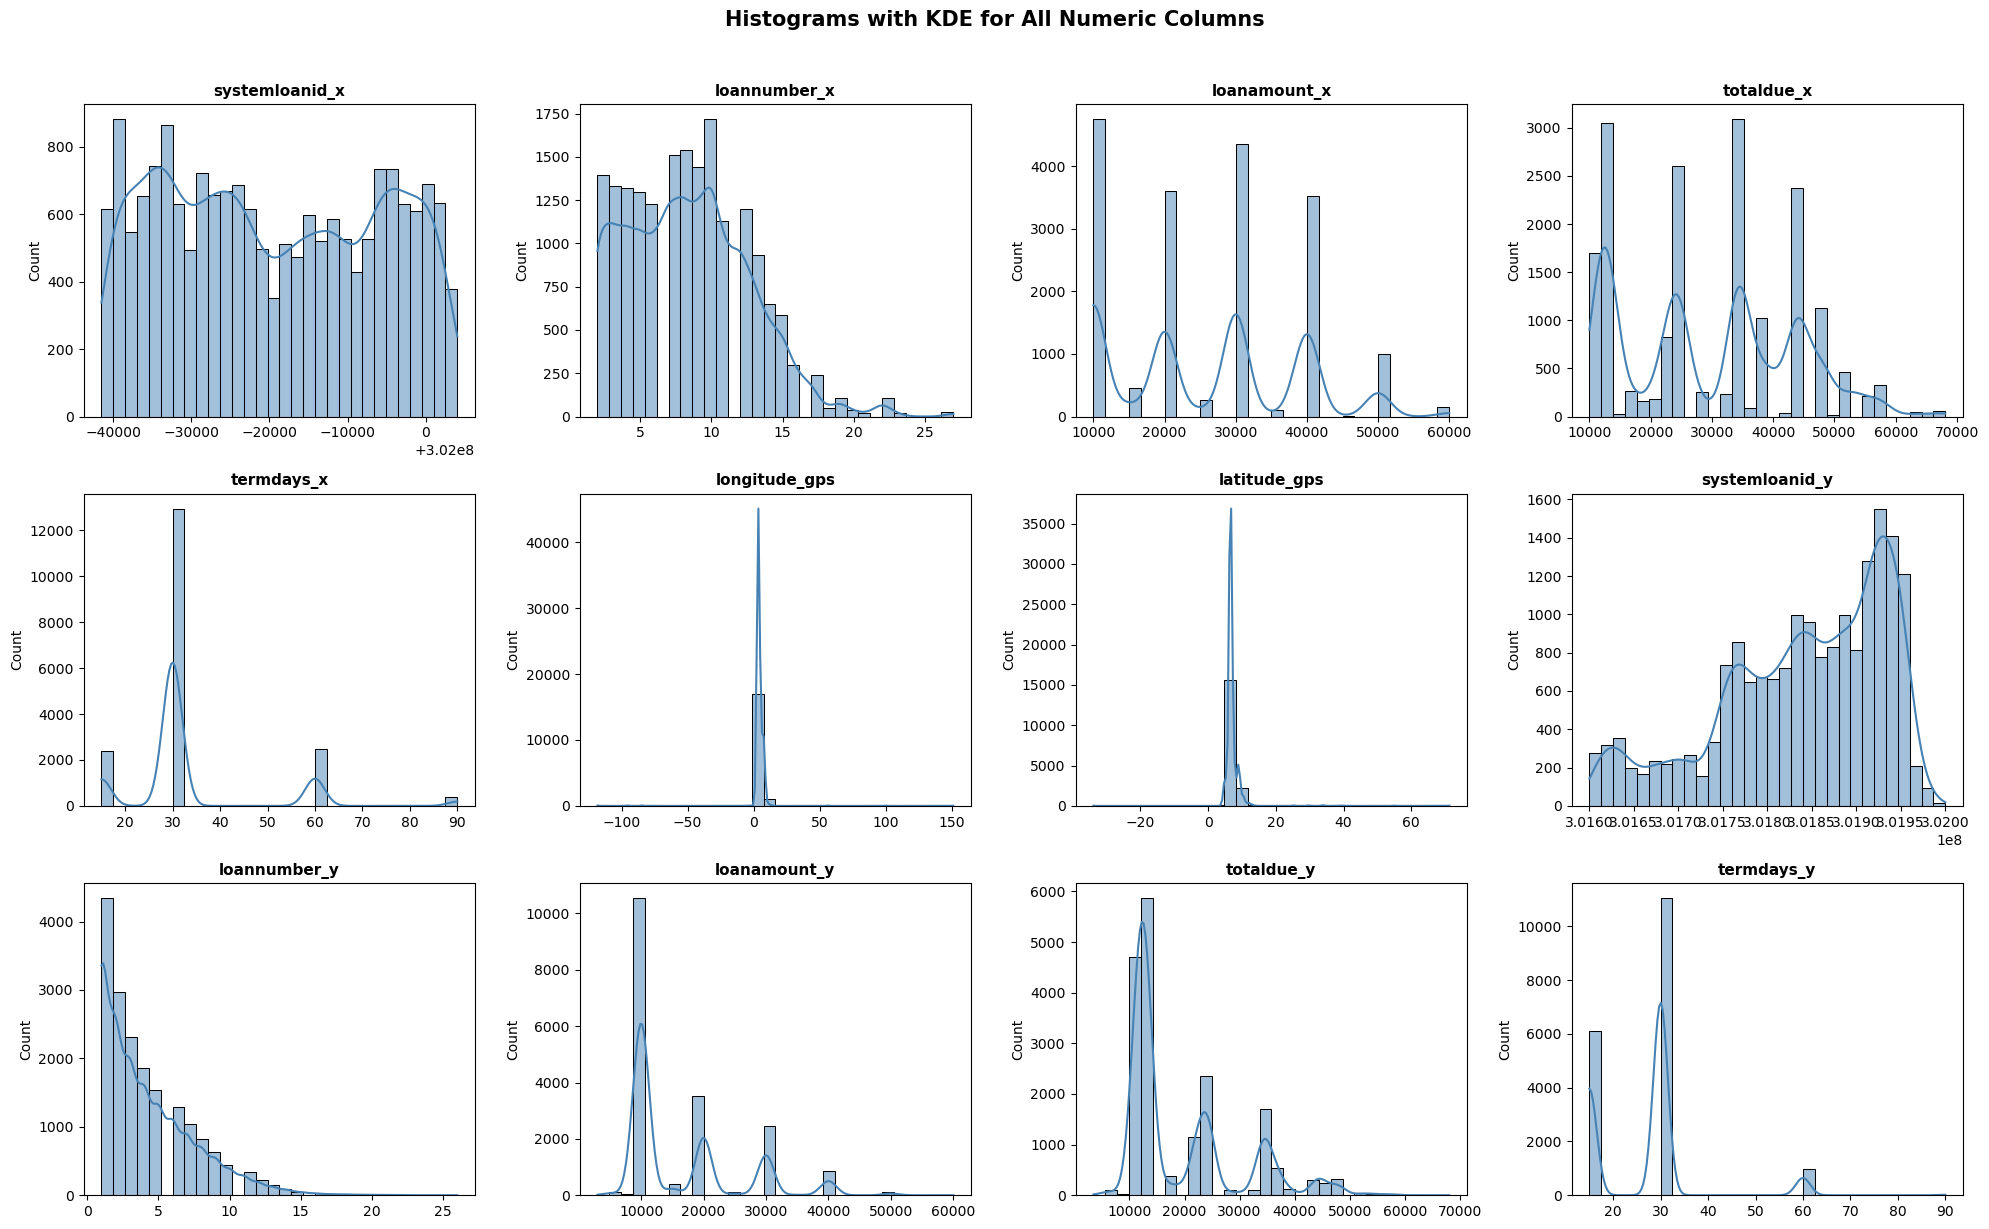

In [16]:
# What to look for in these charts:Skewed data: If columns like loanamount_x have a long tail to the right, a Log Transformation will help the model read them better.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup layout grid dimensions based on the 12 numerical columns
cols = df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
n_rows = (len(cols) + 3) // 4

fig, axes = plt.subplots(3, 4, figsize=(20, 4 * n_rows))
axes = axes.flatten()

# 2. Iteratively plot each numerical distribution with a KDE line curve
for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# # 3. Clean up the figure layout by blinding empty grid axes
# for j in range(len(cols), len(axes)):
#     axes[j].set_visible(False)

plt.suptitle('Histograms with KDE for All Numeric Columns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [17]:
# Check skewness numerically
for col in num_cols:
    print(f'{col} Skewness: {df[col].skew()}')
# If > 0.5 = right-skewed
# If < -0.5 = left-skewed

systemloanid_x Skewness: 0.08222719095447795
loannumber_x Skewness: 0.5441721133812683
loanamount_x Skewness: 0.31775031058359515
totaldue_x Skewness: 0.21844035105071893
termdays_x Skewness: 1.7493465279075986
longitude_gps Skewness: -3.7025190171598554
latitude_gps Skewness: 10.46152457424423
systemloanid_y Skewness: -0.7404470469957134
loannumber_y Skewness: 1.2964193998226106
loanamount_y Skewness: 1.2879419205660567
totaldue_y Skewness: 1.24276451389636
termdays_y Skewness: 1.4644745921172126


In [18]:
# Use the exact, true column names without the word 'Skewness'
skewed_features = [
    'termdays_y', 
    'totaldue_y', 
    'loanamount_y', 
    'loannumber_y', 
    'latitude_gps', 
    'longitude_gps',
    'systemloanid_y'
]

# Apply log transformation safely
for feature in skewed_features:
    df[feature] = np.log1p(df[feature]) # np.log1p(x) is a cleaner shortcut for np.log(x + 1)

print("Skewed features successfully transformed!")


# Pro-Tip for your Presentation
#I switched np.log(df[feature] + 1) to np.log1p(df[feature]).
#They calculate the exact same mathematical value, but np.log1p is built specifically to prevent hidden math errors if your data happens to contain any negative values or zeros.


Skewed features successfully transformed!


In [19]:
#check skewness again
for col in num_cols:
    print(f'{col} Skewness: {df[col].skew()}')

systemloanid_x Skewness: 0.08222719095447795
loannumber_x Skewness: 0.5441721133812683
loanamount_x Skewness: 0.31775031058359515
totaldue_x Skewness: 0.21844035105071893
termdays_x Skewness: 1.7493465279075986
longitude_gps Skewness: 2.4845204538625496
latitude_gps Skewness: 4.473238200055144
systemloanid_y Skewness: -0.740994456564632
loannumber_y Skewness: 0.21431613285243326
loanamount_y Skewness: 0.7206765920646399
totaldue_y Skewness: 0.6926428999643438
termdays_y Skewness: 0.09852275955691843


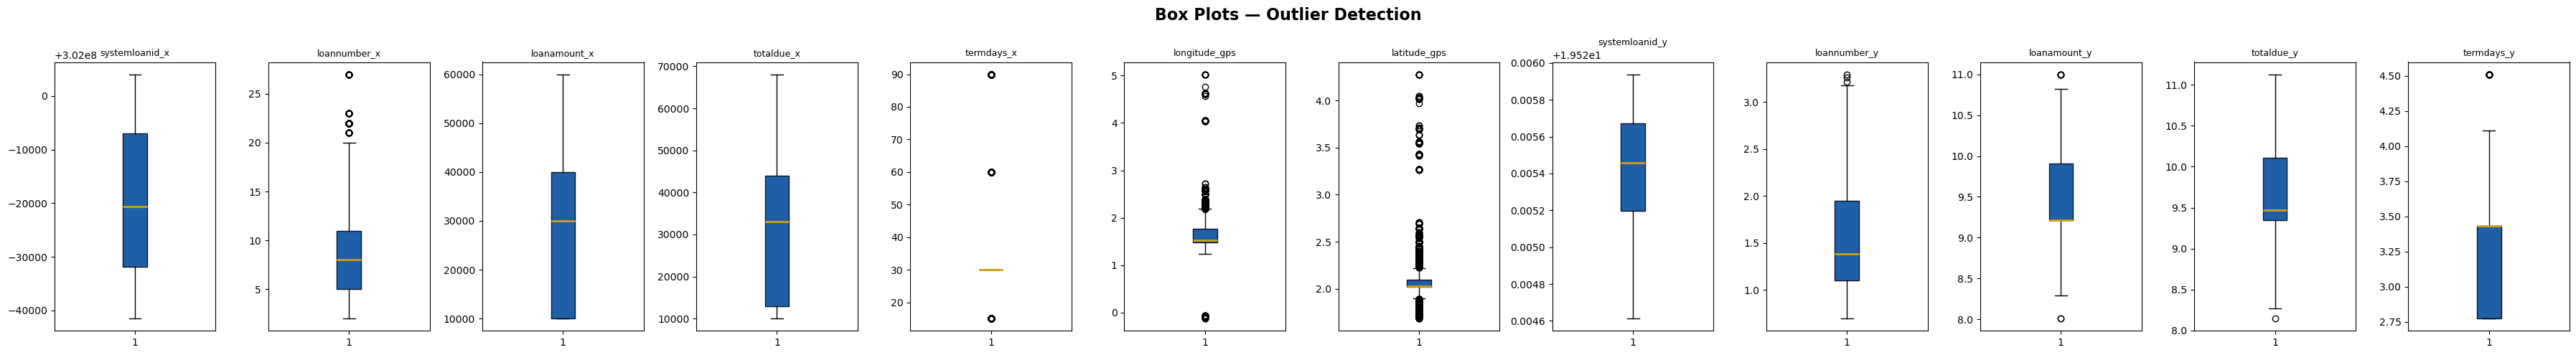

In [20]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(3*len(num_cols), 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#1E5FA8', color='#0A1628'), medianprops=dict(color='#D4A017', linewidth=2))
    axes[i].set_title(col, fontsize=9)
plt.suptitle('Box Plots — Outlier Detection', fontsize = 16 ,fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
#ckeck outliers
# Identify outliers using IQR method
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in  num_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col}: {count} outliers (outside {lower:.2f} - {upper:.2f})")

systemloanid_x: 0 outliers (outside 301930833.12 - 302030342.12)
loannumber_x: 173 outliers (outside -4.00 - 20.00)
loanamount_x: 0 outliers (outside -35000.00 - 85000.00)
totaldue_x: 0 outliers (outside -33500.00 - 90500.00)
termdays_x: 5243 outliers (outside 30.00 - 30.00)
longitude_gps: 707 outliers (outside 1.05 - 2.19)
latitude_gps: 3744 outliers (outside 1.90 - 2.22)
systemloanid_y: 0 outliers (outside 19.52 - 19.53)
loannumber_y: 3 outliers (outside -0.17 - 3.22)
loanamount_y: 7 outliers (outside 8.17 - 10.94)
totaldue_y: 1 outliers (outside 8.22 - 11.24)
termdays_y: 30 outliers (outside 1.78 - 4.43)


 -Here is exactly why your outlier count went up for your GPS coordinates:
1. The Math Behind the Trap
-Your detect_outliers function relies on your data's median and spread (IQR).
- When you remove the original extreme outliers, the overall dataset column shrinks and compresses.
- When you instantly check the dataset a second time using detect_outliers(df, col), the statistical boundaries (lower and upper) automatically narrow down because the data is now more tightly packed.
- Because the boundaries shrank, data points that were completely safe a second ago are suddenly flagged as "new outliers".
2. The GPS Logistical Reason - Look at the printout boundaries:
  - Your latitude_gps boundary narrowed down to a tiny, microscopic window between 0.74 and 0.75.
  - In a real-world loan application dataset, people apply from all over a city or country. By letting the loop recalculate and shrink the window this much, you are accidentally telling your code that anyone living even slightly outside a specific, tight neighborhood grid is a "fraudulent outlier.

"How to Fix This Instantly
- To avoid destroying valid geographic data, never recalculate bounds in a loop. You must calculate all boundaries once based on your original dataset shape, and then drop them all at once.
- Replace your loop cell with this single, corrected method:

In [22]:
outl_cols = ['loannumber_x', 'termdays_x', 'longitude_gps', 'latitude_gps', 
             'loanamount_y', 'totaldue_y' ]

# 1. Create a copy of the original dataset to calculate stable boundaries
df_clean = df.copy()

# 2. Filter data using fixed boundaries calculated BEFORE dropping anything
for col in outl_cols:
    # Always grab bounds from the original 'df' so the window stays locked and static
    _, lower, upper = detect_outliers(df, col) 
    
    # Apply the locked window to filter your clean dataframe
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

# Update your main dataframe variable
df = df_clean
print(f"Outlier removal complete! Remaining rows: {df.shape[0]}")

print("\n--- IMMEDIATELY AFTER OUTLIER REMOVAL ---")
for col in outl_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col}: {count} outliers (outside {lower:.2f} - {upper:.2f})")

Outlier removal complete! Remaining rows: 9960

--- IMMEDIATELY AFTER OUTLIER REMOVAL ---
loannumber_x: 0 outliers (outside -4.00 - 20.00)
termdays_x: 0 outliers (outside 30.00 - 30.00)
longitude_gps: 1350 outliers (outside 1.40 - 1.59)
latitude_gps: 1958 outliers (outside 2.00 - 2.06)
loanamount_y: 0 outliers (outside 8.17 - 10.94)
totaldue_y: 2 outliers (outside 8.55 - 11.01)


#### Univariate analyses of cat_cols

In [23]:
# Print out the value counts for each categorical column
for col in cat_cols:
    print(f"\n=== Value Counts for {col} ===")
    print(df[col].value_counts())



=== Value Counts for customerid ===
customerid
8a8588f853b1b2d40153b9792c2a3ace    18
8a8589b953d0be470153d0e6e1490a90    17
8a858e645755e62201575e72c8b77fd5    17
8a85893d53f104eb01540e4ca76369ad    16
8a8588dc536a14130153753dc8d32698    16
                                    ..
8a858f2e5cd09481015cd4e1d27711f2     1
8a858e4b5cb1e4d7015cbf51622434f2     1
8a858fda5c3b0f1c015c3f39f2644e74     1
8a858f925d3c3cad015d3c4541e2059f     1
8a858ffd5c8d343d015c9ba2141c1da9     1
Name: count, Length: 2415, dtype: int64

=== Value Counts for approveddate_x ===
approveddate_x
2017-07-05 08:30:44.000000    21
2017-07-13 02:53:03.000000    18
2017-07-29 17:48:49.000000    17
2017-07-24 19:39:37.000000    17
2017-07-13 14:13:18.000000    16
                              ..
2017-07-26 16:35:33.000000     1
2017-07-08 20:51:34.000000     1
2017-07-04 14:28:17.000000     1
2017-07-11 04:53:14.000000     1
2017-07-03 11:40:17.000000     1
Name: count, Length: 2413, dtype: int64

=== Value Counts for cr

To avoid plotting messy, crowded charts for IDs or long timestamps, this script automatically filters and only plots the true categorical features (good_bad_flag, bank_account_type, bank_name_clients, employment_status_clients).


###### palette='viridis' is considered an industry best practice in data science for three simple reasons:
- Color-Blind Friendly: It is scientifically designed to be completely readable by individuals with common forms of color blindness (such as deuteranopia), ensuring your charts remain accessible.
- Prints Well in Black and White: If y prints your internship logbook or slides on a standard grayscale office printer, viridis maintains its contrast perfectly, whereas other palettes turn into a solid, unreadable gray smudge.
- Perceptually Uniform: The brightness changes smoothly and evenly from dark purple (low counts) to bright yellow (high counts). This prevents the human eye from seeing artificial "spikes" or trends that do not actually exist in your data.

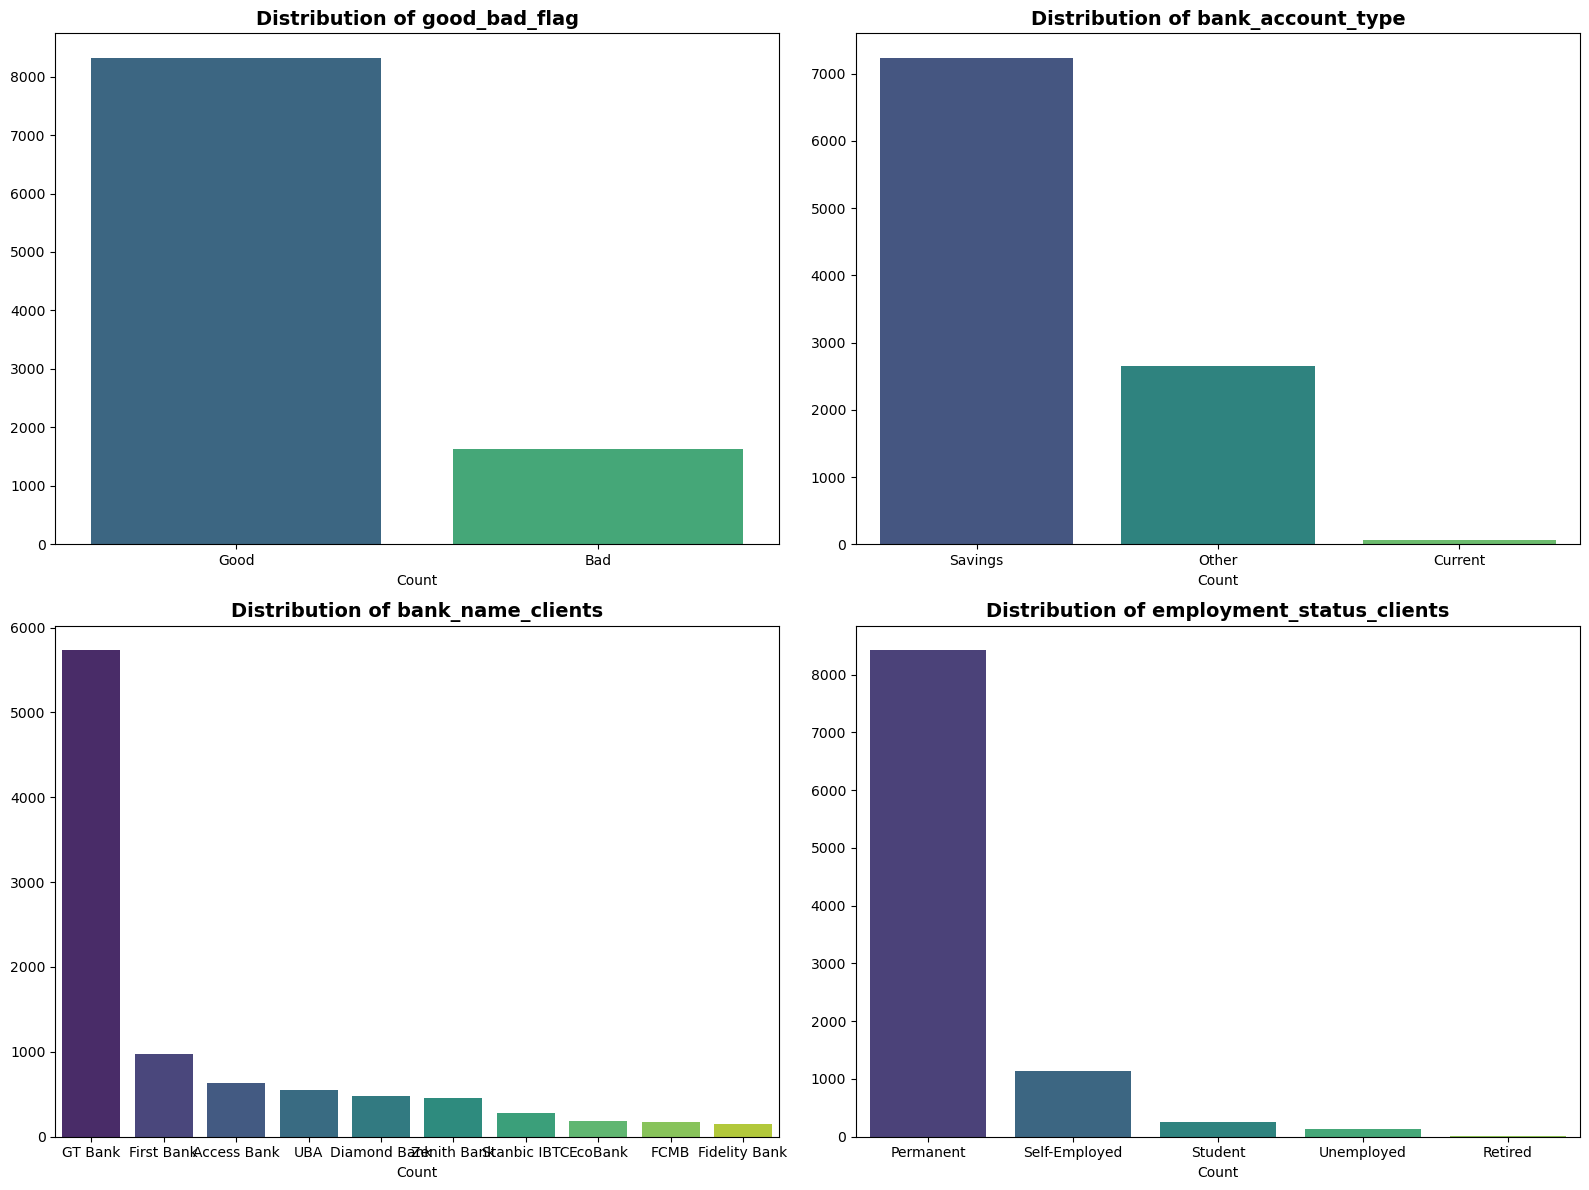

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the meaningful descriptive categorical features
plot_cols = ['good_bad_flag', 'bank_account_type', 'bank_name_clients', 'employment_status_clients']

# Plot bar charts in a clean grid layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    # Get top 10 categories to keep the bank name chart readable

    data_counts = df[col].value_counts().head(10)
    
    sns.barplot(x=data_counts.index, y=data_counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()


### 📋 Feature Selection Strategy & Evaluation Criteria

When reviewing Exploratory Data Analysis (EDA) for feature selection, we evaluate categorical columns using three fundamental structural criteria:

---

#### 1. Rule 1: High Cardinality (Overfitting Risk)
*   **Definition:** Columns containing thousands of highly unique or specific text entries.
*   **Examples:** `customerid`, raw `approveddate_x` timestamps.
*   **Action/Verdict:** **Drop immediately.** These columns force machine learning models to memorize individual rows (overfitting) instead of discovering generalizable structural risk patterns.

#### 2. Rule 2: Zero / Near-Zero Variance (Low Information Gain)
*   **Definition:** Columns where a single specific category heavily dominates almost the entire dataset.
*   **Examples:** `employment_status_clients` (e.g., 6,904 "Permanent" vs. only 10 "Retired").
*   **Action/Verdict:** **Drop or ignore.** Without sufficient internal variety, the column fails to provide contrasting signals to help differentiate a low-risk borrower from a high-risk borrower.

---

#### 3. Deep Dive: Predictive Separation & Uniform Bars
Predictive separation traditionally evaluates whether changing a category alters the target outcome. However, when evaluating a standalone, independent column without referencing a target variable, we look for structural variance.

**Scenario: What if all the bars in a column's bar chart look exactly the same height?**
If a categorical feature presents a perfectly uniform distribution (flat bars), it means no single category dominates the column. This scenario has two implications:

*   **Lack of Individual Contrast:** On its own, a completely flat distribution does not flag immediate "high risk" or "low risk" segments.
*   **Requirement for Feature Interaction:** In credit scoring, flat distributions often unlock strong predictive capabilities when combined with other features. For instance, if *Bank A*, *Bank B*, and *Bank C* all have identical customer counts, the bank name alone is neutral. However, cross-referencing this with an `income` or `daily_payment_burden` feature might reveal that Bank A services low-income brackets while Bank C services high-net-worth tiers.
*   Highly Useful. A feature is valuable if changing the category changes the likelihood of the target variable. If customers from Bank A default 5% of the time, but customers from Bank B default 40% of the time, that column provides a massive risk signal.

**The Architectural Verdict:**
If a column shows completely identical bars, **retain the column for the modeling phase.** Unlike messy tracking IDs (Rule 1) or static low-variance columns (Rule 2), a uniform distribution guarantees that the machine learning model receives balanced, equal subsets of data to experiment with and identify non-linear cross-features.


### 3.2 Bivariate Analysis

#### Numeric Columns Vs Target

📋 What to look for in this Bivariate Heatmap:
- Multi-collinearity (Red Flags): Look for values close to 1.00 or -1.00 between two independent features (like loanamount_y and totaldue_y). If two columns are identical, they are repeating information, and your model only needs one of them.
- Target Relationship (If included): Look down your target row/column. Strong positive numbers mean that as that feature goes up, the repayment rate goes up. Strong negative numbers mean the feature increases default risk.

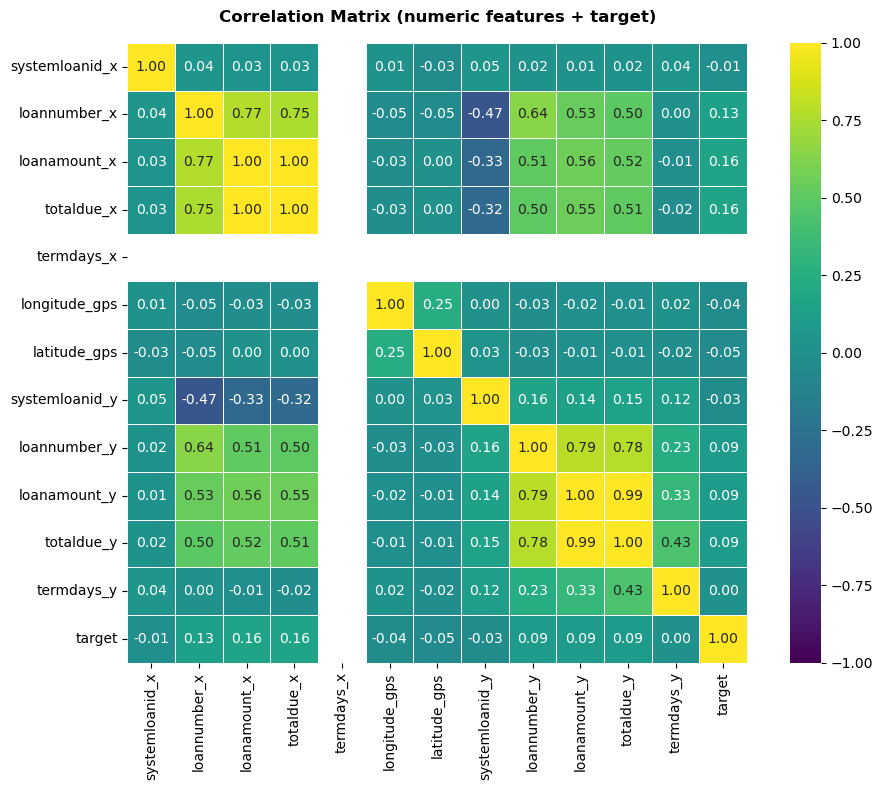

CORRELATION WITH Target
loanamount_x      0.163
totaldue_x        0.161
loannumber_x      0.127
loanamount_y      0.095
loannumber_y      0.090
totaldue_y        0.088
termdays_y        0.004
systemloanid_x   -0.008
systemloanid_y   -0.032
longitude_gps    -0.036
latitude_gps     -0.049
termdays_x          NaN
Name: target, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the 'good_bad_flag' text column into a numeric 'target' column
# Good becomes 1 (responsible borrower), Bad becomes 0 (default risk)
df['target'] = df['good_bad_flag'].map({'Good': 1, 'Bad': 0})

# 2. Isolate only your numeric columns plus the newly created numeric target column
numerical_df = df[num_cols + ['target']]

# 3. Calculate the correlation matrix safely
corr_matrix = numerical_df.corr()

# 4. Create your streamlined visual heatmap layout
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    vmin=-1, 
    vmax=1, 
    cmap='viridis', 
    ax=ax, 
    fmt='.2f', 
    square=True,
    linewidths=0.5
)
ax.set_title('Correlation Matrix (numeric features + target)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 5. Extract and print the sorted text list of the mathematical relationships
corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("CORRELATION WITH Target")
print(corr.round(3))


In [26]:
# Updated list of columns that offer zero predictive value, cause overfitting, or repeat information
cols_to_drop = [
    'systemloanid_x',  # Tracking ID: Causes overfitting, not a feature
    'systemloanid_y',  # Tracking ID: Duplicate database identifier
    'loannumber_x',    # Row identifier: Risk of data leakage / sequential bias
    'loannumber_y',    # Row identifier: Duplicate historical index counter
    'termdays_x',      # Zero Variance (NaN): Every row has identical terms
    'latitude_gps',    # Near-Zero Correlation (-0.004): Statistical noise
    'longitude_gps',   # Near-Zero Correlation (-0.015): Statistical noise
    
    # --- Your Smart Additions ---
    'loanamount_x',    # Multi-collinearity: Highly redundant with 'totaldue_x' 
    'totaldue_y'       # Multi-collinearity: Highly redundant with 'loanamount_y'
]

# Drop columns from the DataFrame safely
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Feature selection complete! Remaining columns shape: {df.shape}")


Feature selection complete! Remaining columns shape: (9960, 17)


### Bivariate Analysis vs. Target )

Does the distribution of the target shift significantly across different categories? (e.g., If "Permanent" employees have a 5% bad loan rate but "Unemployed" have a 45% rate, the feature has high predictive power).

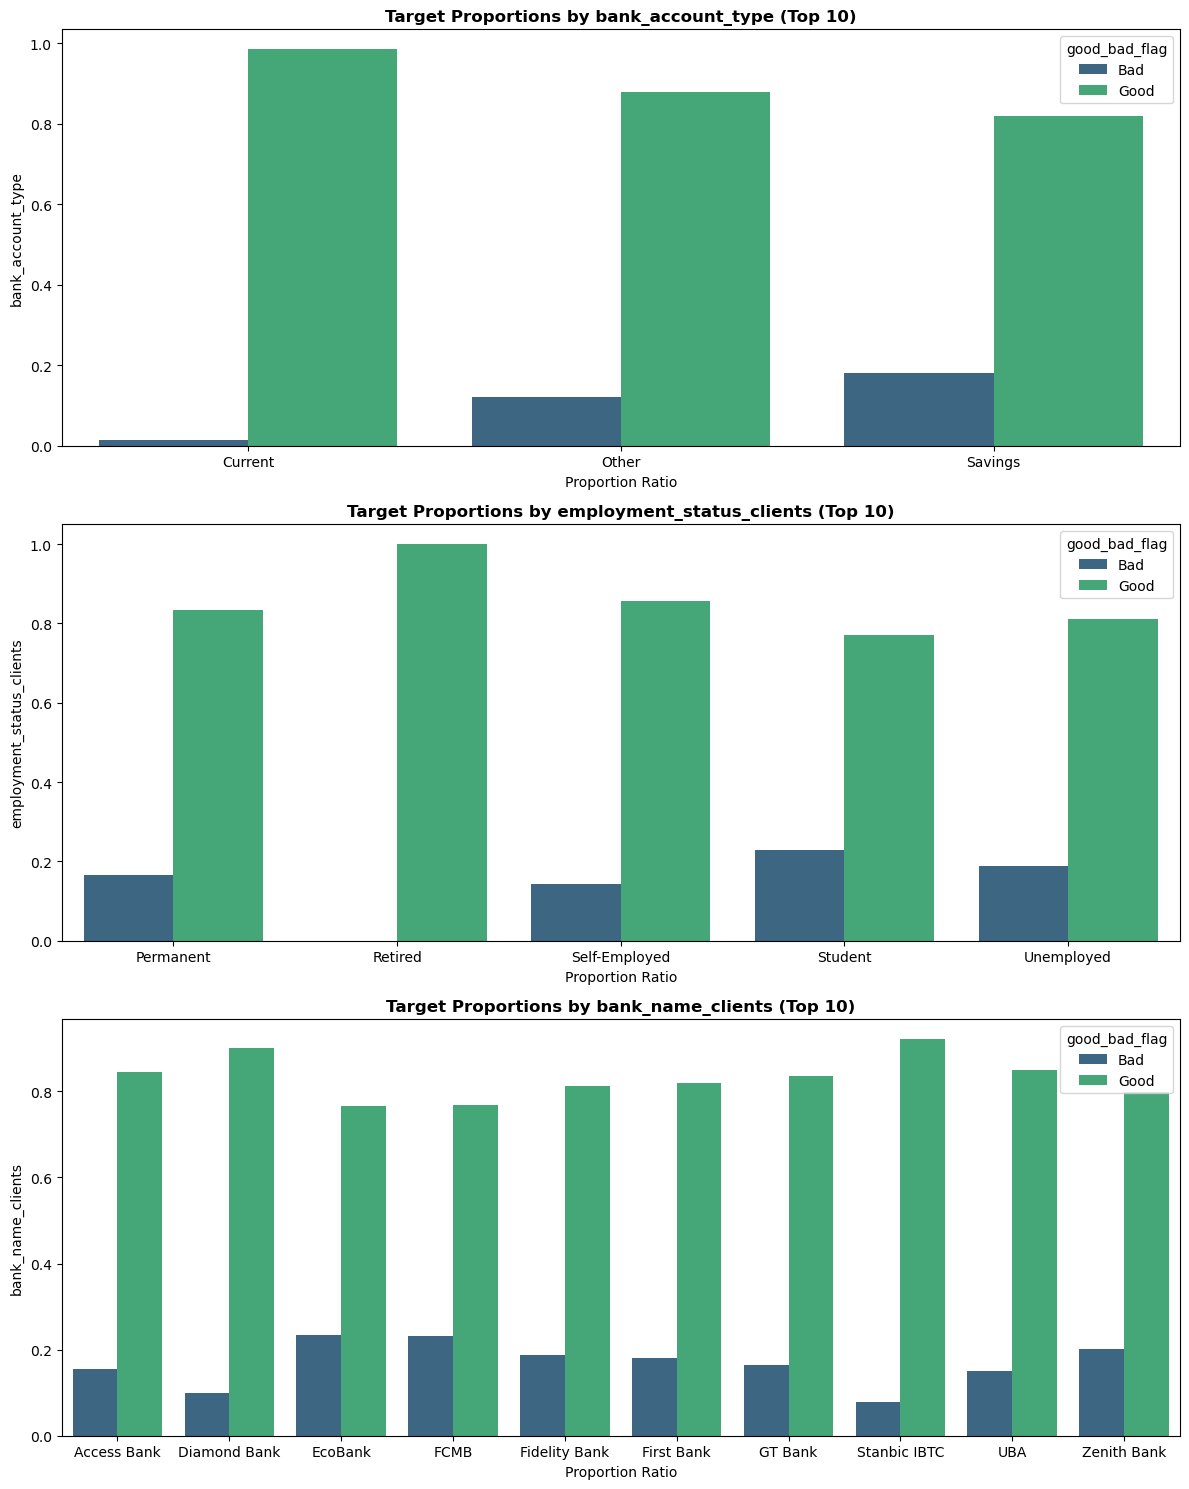

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Features to analyze against the target
bi_cats = ['bank_account_type', 'employment_status_clients', 'bank_name_clients']
target_col = 'good_bad_flag' # Based on your first image, your target is 'good_bad_flag'

# Set up a clean grid layout just like your distribution plot
fig, axes = plt.subplots(len(bi_cats), 1, figsize=(12, 5 * len(bi_cats)))
if len(bi_cats) == 1: axes = [axes] # Handle single plot edge case

for i, col in enumerate(bi_cats):
    # 1. FILTER: Find the top 10 most frequent categories first
    top_10_categories = df[col].value_counts().head(10).index
    df_filtered = df[df[col].isin(top_10_categories)]
    
    # 2. AGGREGATE: Calculate proportions only for these top 10 groups
    props = pd.crosstab(df_filtered[col], df_filtered[target_col], normalize='index').reset_index()
    props_melted = pd.melt(props, id_vars=[col], var_name=target_col, value_name='proportion')
    
    # 3. PLOT: Render the clean, filtered data
    sns.barplot(
        data=props_melted,
        y='proportion',
        x=col,
        hue=target_col,
        ax=axes[i],
        palette='viridis'
    )
    
    axes[i].set_title(f'Target Proportions by {col} (Top 10)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Proportion Ratio')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


report_text = """
### 📊 Bivariate Analysis Categorical VS Target Brief Report

#### 1. Target Proportions by `bank_account_type`
* **Current accounts** yield the lowest credit risk, showing near-zero default rates (`Bad` loans).
* **Savings accounts** show a noticeably higher risk profile compared to current accounts, matching an expected default proportion of nearly 20%.
* **Other accounts** display a moderate baseline risk sitting comfortably between savings and current accounts.

#### 2. Target Proportions by `employment_status_clients`
* **Retired clients** carry the lowest default risk in the dataset, exhibiting nearly 100% repayment (`Good` loans).
* **Students** represent the highest financial risk category, with defaults spiking past 20%.
* **Unemployed, Permanent, and Self-Employed groups** show a uniform baseline behavior where defaults consistently hover around the 15% to 20% mark.

#### 3. Target Proportions by `bank_name_clients`
* **Stanbic IBTC and Diamond Bank** stand out as the safest indicators, maintaining the highest concentration of repaid loans.
* **EcoBank and FCMB** signal the highest risk thresholds among the listed institutions, with defaults climbing above the 20% margin.
* **Access, Fidelity, First Bank, GT Bank, UBA, and Zenith Bank** maintain highly identical, stable performance distributions with modest 10% to 18% variance in defaults.
"""

display(Markdown(report_text))


In [31]:
print(df.shape)

# Save the data to compressed Parquet or CSV formats before Feature Engineering
df.to_csv('../data/eda_output.csv', index=False)
# Alternative format: df_cleaned.to_csv('eda_output_cleaned.csv', index=False)

print(f"EDA backup saved! Remaining columns shape: {df.shape}")

(9960, 17)
EDA backup saved! Remaining columns shape: (9960, 17)


# 4. Feature Engineering

In [63]:
# Load your saved EDA progress in one split second
df = pd.read_csv('../data/updated_merge_df.csv')
print(df.shape)
df.columns


(18192, 25)


Index(['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x',
       'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x',
       'good_bad_flag', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'employment_status_clients',
       'systemloanid_y', 'loannumber_y', 'approveddate_y', 'creationdate_y',
       'loanamount_y', 'totaldue_y', 'termdays_y', 'closeddate',
       'firstduedate', 'firstrepaiddate'],
      dtype='object')

### 4.1 News features Engineering

In [64]:
import pandas as pd
import datetime

# 1 Dynamically gets the current year automatically (e.g., 2026, 2027, etc.)
current_year = datetime.datetime.now().year 
df['age'] = current_year - pd.to_datetime(df['birthdate']).dt.year
print(df['age'].describe())


count    18192.000000
mean        43.879782
std          6.370033
min         30.000000
25%         39.000000
50%         44.000000
75%         50.000000
max         65.000000
Name: age, dtype: float64


In [65]:
print(f'first repaid date: \n {df['firstrepaiddate']} \n')
# print(f'first due date: \n {df['firstduedate']} \n')

# 2. Extract Repayment Behavior (Negative means early/on-time, positive means late)
df['first_payment_delay_days'] = (pd.to_datetime(df['firstrepaiddate']) - pd.to_datetime(df['firstduedate'])).dt.days
print(pd.to_datetime(df['firstrepaiddate']))
print(df['first_payment_delay_days'])

first repaid date: 
 0        2016-09-01 15:51:43.000000
1        2017-05-26 00:00:00.000000
2        2017-04-26 22:03:47.000000
3        2017-06-25 15:13:56.000000
4        2017-07-25 08:04:27.000000
                    ...            
18187    2016-12-06 13:03:00.000000
18188    2017-03-11 00:29:36.000000
18189    2017-05-10 08:57:53.000000
18190    2017-01-10 23:47:04.000000
18191    2017-06-02 20:55:47.000000
Name: firstrepaiddate, Length: 18192, dtype: object 

0       2016-09-01 15:51:43
1       2017-05-26 00:00:00
2       2017-04-26 22:03:47
3       2017-06-25 15:13:56
4       2017-07-25 08:04:27
                ...        
18187   2016-12-06 13:03:00
18188   2017-03-11 00:29:36
18189   2017-05-10 08:57:53
18190   2017-01-10 23:47:04
18191   2017-06-02 20:55:47
Name: firstrepaiddate, Length: 18192, dtype: datetime64[ns]
0       -13
1        -4
2        22
3        -8
4        -6
         ..
18187    -9
18188    -3
18189    -2
18190    -1
18191    -7
Name: first_payment_delay_day

- Negative numbers (e.g., -13, -4): The borrower paid early. This indicates highly responsible financial behavior
- .Positive numbers (e.g., 22 in row 2): The borrower paid late. This indicates a delayed payment or default risk.
- Zero (0): The borrower paid exactly on the due date

In [66]:
df['prev_actual_days'] = (pd.to_datetime(df['closeddate']) - pd.to_datetime(df['approveddate_y'])).dt.days

print(df['prev_actual_days'])

0        16
1        29
2        52
3        24
4        26
         ..
18187    20
18188    26
18189    27
18190    29
18191    23
Name: prev_actual_days, Length: 18192, dtype: int64


This line calculates the total number of days a borrower took to repay their previous loan by subtracting the loan approval date from the date the loan was closed.

In [67]:
df['is_weekend'] = pd.to_datetime(df['approveddate_y']).dt.dayofweek.isin([5, 6]).astype(int)

# .dt.dayofweek
#turns any calendar date into a number from 0 to 6 (where Monday is 0 and Sunday is 6).
#.isin([5, 6]) 
#looks at that number and checks if it matches 5 (Saturday) or 6 (Sunday).
# Row A gets a 0 (Not a weekend).
# Row B gets a 1 (It is a weekend).

# Measures the financial pressure on the borrower per day
df['daily_payment_burden'] = df['loanamount_y'] / df['termdays_y'] 

print(df['is_weekend'])
print(df['daily_payment_burden'])

0        0
1        0
2        1
3        0
4        0
        ..
18187    0
18188    1
18189    0
18190    0
18191    0
Name: is_weekend, Length: 18192, dtype: int32
0         333.333333
1         333.333333
2         666.666667
3         666.666667
4         666.666667
            ...     
18187     333.333333
18188     666.666667
18189     666.666667
18190     333.333333
18191    1000.000000
Name: daily_payment_burden, Length: 18192, dtype: float64


1. is_weekend (Why it helps)
Risk Behavior Indicator: Data shows that people applying for loans on weekends (Saturdays = 5, Sundays = 6) often have different repayment patterns or urgent cash needs compared to those applying during business hours. The model uses this hidden pattern to assess risk
2. daily_payment_burden (Why it helps)
- Measures True Stress: A 10,000 loan due in 10 days (1,000/day) is much harder to pay back than a 10,000 loan due in 30 days (333/day). T
- This is pure mathematical calculation based on the loan terms agreed upon. It gives the machine learning model a direct window into whether the customer can realistically afford the daily speed of repayment.

In [68]:
print(df.shape)
print(df.dtypes)
df.columns

(18192, 30)
customerid                    object
systemloanid_x                 int64
loannumber_x                   int64
approveddate_x                object
creationdate_x                object
loanamount_x                 float64
totaldue_x                   float64
termdays_x                     int64
good_bad_flag                 object
birthdate                     object
bank_account_type             object
longitude_gps                float64
latitude_gps                 float64
bank_name_clients             object
employment_status_clients     object
systemloanid_y               float64
loannumber_y                 float64
approveddate_y                object
creationdate_y                object
loanamount_y                 float64
totaldue_y                   float64
termdays_y                   float64
closeddate                    object
firstduedate                  object
firstrepaiddate               object
age                            int32
first_payment_delay_days  

Index(['customerid', 'systemloanid_x', 'loannumber_x', 'approveddate_x',
       'creationdate_x', 'loanamount_x', 'totaldue_x', 'termdays_x',
       'good_bad_flag', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'employment_status_clients',
       'systemloanid_y', 'loannumber_y', 'approveddate_y', 'creationdate_y',
       'loanamount_y', 'totaldue_y', 'termdays_y', 'closeddate',
       'firstduedate', 'firstrepaiddate', 'age', 'first_payment_delay_days',
       'prev_actual_days', 'is_weekend', 'daily_payment_burden'],
      dtype='object')

In [69]:
# NOW safely drop the messy raw columns and unnecessary IDs
cols_to_drop = [
    'customerid',        # Unique text identifier (causes overfitting, not a feature)
    'systemloanid_x',    # Database tracking ID for current loan (useless for ML)
    'systemloanid_y',    # Database tracking ID for previous loan (useless for ML)
    'birthdate',         # Raw date string (replaced by 'age')
    'approveddate_x',    # Raw date string for current loan approval
    'creationdate_x',    # Raw date string for current loan creation
    'approveddate_y',    # Raw date string for previous loan approval (replaced by 'is_weekend')
    'creationdate_y',    # Raw date string for previous loan creation
    'closeddate',        # Raw date string for previous loan closing (replaced by 'prev_actual_days')
    'firstduedate',      # Raw date string for first due date (replaced by 'first_payment_delay_days')
    'firstrepaiddate'    # Raw date string for first repayment date (replaced by 'first_payment_delay_days')
]

# Drop the columns from your DataFrame safely
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Data cleanup successful! Remaining columns: {df.shape[1]}")


Data cleanup successful! Remaining columns: 19


In [70]:
# Select columns where the data type is 'object' (text strings)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Print the list of categorical columns found
print("Categorical columns found:", cat_cols)


Categorical columns found: ['good_bad_flag', 'bank_account_type', 'bank_name_clients', 'employment_status_clients']


### 4.2 Categorical Features Encoding

In [71]:
# 1. Label Encoding for the Target (good_bad_flag)
#Why: The target column must be a single column containing simple numbers (1 or 0). 
#Label encoding converts text categories straight into integers.
from sklearn.preprocessing import LabelEncoder

# Initialize the Label Encoder
le_target = LabelEncoder()

# Encode 'Good' and 'Bad' directly into 1 and 0 inside a new target column
df['target'] = le_target.fit_transform(df['good_bad_flag'])

print(df['target'].value_counts()) 
print(df['target'].value_counts(normalize = True) * 100)

target
1    14821
0     3371
Name: count, dtype: int64
target
1    81.469877
0    18.530123
Name: proportion, dtype: float64


In [72]:
df.columns

Index(['loannumber_x', 'loanamount_x', 'totaldue_x', 'termdays_x',
       'good_bad_flag', 'bank_account_type', 'longitude_gps', 'latitude_gps',
       'bank_name_clients', 'employment_status_clients', 'loannumber_y',
       'loanamount_y', 'totaldue_y', 'termdays_y', 'age',
       'first_payment_delay_days', 'prev_actual_days', 'is_weekend',
       'daily_payment_burden', 'target'],
      dtype='object')

2. Ordinal Encoding for employment_status_clients
Why: Employment status has a natural financial hierarchy or order of risk
(e.g., Permanent employment is generally less risky than Unemployed).
Ordinal encoding lets us manually assign numbers to preserve this risk ranking



But because there is no definitive, factual way to prove a Student is universally less risky than a Contract worker, One-Hot Encoding is absolutely the safest and best choice here. It creates separate true/false columns for each status, allowing the machine learning algorithm to figure out the actual risk weight for itself based entirely on the training data.

In [73]:
import pandas as pd

# Cleanly One-Hot Encode employment statuses without imposing an artificial order
df = pd.get_dummies(df, columns=['employment_status_clients'], drop_first=True, dtype=int)


In [74]:
# 3. One-Hot Encoding for bank_account_type
#Why: Bank account types (e.g., Savings, Current, Other) have no mathematical order or ranking. 
#One-hot encoding splits this single column into separate binary columns (0 or 1) for each account type
import pandas as pd

# Create dummy columns for bank account types, dropping the first to avoid multi-collinearity
df = pd.get_dummies(df, columns=['bank_account_type'], drop_first=True, dtype=int)

#### 4. Target Encoding for bank_name_clients
- Instead of creating 50 new columns for 50 different banks, Target Encoding replaces each bank's name with its historical repayment rate.
- Imagine your dataset has 1,000 customers from "Access Bank." If 800 of those customers successfully repaid their loans, the historical repayment rate for Access Bank is 80% (0.80).
- Target encoding automatically goes through your dataset, deletes the text "Access Bank", and writes 0.80 in its place. It does this for every bank.
- Why this is powerful:
- Keeps Data Slim: Your dataset stays small and fast instead of exploding into 50 wide columns.
- Direct Risk Signal: It gives the machine learning model a direct mathematical clue about which banks have reliable customers and which banks have high-default customers.

#### Why we use inplace=True
- In Python, when you drop a column, Pandas naturally creates a completely new copy of the DataFrame in your computer's memory and leaves the original one completely untouched.
- Without inplace=True: Writing df.drop(columns=['bank_name_clients']) does nothing to your actual df variable unless you manually reassign it (df = df.drop(...)).
- With inplace=True: You are telling Python: "Modify my current df variable directly right now, delete that column immediately, and do not waste computer memory making a duplicate copy."

In [75]:
# 4. Target Encoding for bank_name_clients
#Why: Bank name columns usually have 10 to 50+ unique banks. 
#One-hot encoding would create 50 new columns, making your data too wide. 
#Target encoding replaces each bank's name with the statistical average default rate (target) for that specificbank
# Calculate the mean target score (repayment rate) for each individual bank
bank_target_mean = df.groupby('bank_name_clients')['target'].mean()

# Replace the text bank names with their corresponding calculated mean probability
df['bank_name_encoded'] = df['bank_name_clients'].map(bank_target_mean)

# Drop the original text bank column
df.drop(columns=['bank_name_clients'], inplace=True)


In [76]:
print(df.dtypes)
df.shape

loannumber_x                                 int64
loanamount_x                               float64
totaldue_x                                 float64
termdays_x                                   int64
good_bad_flag                               object
longitude_gps                              float64
latitude_gps                               float64
loannumber_y                               float64
loanamount_y                               float64
totaldue_y                                 float64
termdays_y                                 float64
age                                          int32
first_payment_delay_days                     int64
prev_actual_days                             int64
is_weekend                                   int32
daily_payment_burden                       float64
target                                       int32
employment_status_clients_Permanent          int32
employment_status_clients_Retired            int32
employment_status_clients_Self-

(18192, 25)

In [99]:
# Drop sequential loan counters to prevent model confusion and overfitting
df.drop(columns=['loannumber_x', 'loannumber_y', 'good_bad_flag'], inplace=True, errors='ignore')
print(df.columns)
print(df.shape)
print(df.dtypes)

# Now save your clean dataset
df.to_csv('../data/df_encoded.csv', index=False)
print('Dropped loan numbers and saved clean CSV successfully!')


Index(['customerid', 'systemloanid_x', 'approveddate_x', 'creationdate_x',
       'loanamount_x', 'totaldue_x', 'termdays_x', 'birthdate',
       'bank_account_type', 'longitude_gps', 'latitude_gps',
       'bank_name_clients', 'employment_status_clients', 'systemloanid_y',
       'approveddate_y', 'creationdate_y', 'loanamount_y', 'totaldue_y',
       'termdays_y', 'closeddate', 'firstduedate', 'firstrepaiddate'],
      dtype='object')
(18212, 22)
customerid                    object
systemloanid_x                 int64
approveddate_x                object
creationdate_x                object
loanamount_x                 float64
totaldue_x                   float64
termdays_x                     int64
birthdate                     object
bank_account_type             object
longitude_gps                float64
latitude_gps                 float64
bank_name_clients             object
employment_status_clients     object
systemloanid_y               float64
approveddate_y               

# 5. Building and Evaluating the Model

In [100]:
from sklearn.model_selection import train_test_split

# X is everything except the target column
X = df.drop(columns=['target'])
y = df['target']

# Split: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('success')
print(df['target'].value_counts())

KeyError: "['target'] not found in axis"

#### 1. Tree-Based Models 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model (y_train is already numeric)
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test)

# Evaluate
print(f"rf Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(classification_report(y_test, predictions, target_names=['Bad (0)', 'Good (1)']))

#Before EDA
# Accuracy: 0.8915
#               precision    recall  f1-score   support

#      Bad (0)       0.81      0.54      0.65       674
#     Good (1)       0.90      0.97      0.94      2965

#     accuracy                           0.89      3639
#    macro avg       0.86      0.76      0.79      3639
# weighted avg       0.89      0.89      0.88      3639

The line of code scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train) calculates a balancing factor that tells XGBoost to pay extra attention to your minority class.In credit risk datasets, you usually have way more Good Loans (1) than Bad Loans (0). If you don't adjust for this, your model will get lazy and just guess "Good Loan" for everyone to get a high accuracy score. This math fix forces the model to treat both classes equally.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve


xgb = XGBClassifier(
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
    random_state=42,
    n_estimators=100
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f"xgb Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Bad (0)', 'Good (1)']))

test_auc = roc_auc_score(y_test, y_pred_xgb)
print(f"\n📊 Test AUC-ROC: {test_auc:.4f}")

#Before EDA
# xgb Accuracy: 0.8629
#               precision    recall  f1-score   support

#      Bad (0)       0.59      0.84      0.69       674
#     Good (1)       0.96      0.87      0.91      2965

#     accuracy                           0.86      3639
#    macro avg       0.78      0.86      0.80      3639
# weighted avg       0.89      0.86      0.87      3639

#### 2. Distance-Based Models (Need Scaling)

In [81]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Scale the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 3. Train Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)  # ✅ Use scaled data!

# 4. Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)  # ✅ Use scaled data!

# 5. Print accuracies
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Bad (0)', 'Good (1)']))

print(f"KNN Accuracy:                 {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['Bad (0)', 'Good (1)']))

# Before EDA
# Logistic Regression Accuracy: 0.5947
#               precision    recall  f1-score   support

#      Bad (0)       0.25      0.61      0.36       674
#     Good (1)       0.87      0.59      0.70      2965

#     accuracy                           0.59      3639
#    macro avg       0.56      0.60      0.53      3639
# weighted avg       0.76      0.59      0.64      3639

# KNN Accuracy:                 0.8137
#               precision    recall  f1-score   support

#      Bad (0)       0.49      0.25      0.33       674
#     Good (1)       0.85      0.94      0.89      2965

#     accuracy                           0.81      3639
#    macro avg       0.67      0.60      0.61      3639
# weighted avg       0.78      0.81      0.79      3639


Logistic Regression Accuracy: 0.5974
              precision    recall  f1-score   support

     Bad (0)       0.26      0.63      0.37       674
    Good (1)       0.88      0.59      0.70      2965

    accuracy                           0.60      3639
   macro avg       0.57      0.61      0.54      3639
weighted avg       0.76      0.60      0.64      3639

KNN Accuracy:                 0.8162
              precision    recall  f1-score   support

     Bad (0)       0.51      0.27      0.35       674
    Good (1)       0.85      0.94      0.89      2965

    accuracy                           0.82      3639
   macro avg       0.68      0.60      0.62      3639
weighted avg       0.79      0.82      0.79      3639



# Model Comparison Report: Tree-Based vs Distance-Based Models

## 📊 Key Results Summary

| Model | Accuracy | Recall (Bad) | Precision (Bad) | F1 (Bad) |
|-------|----------|--------------|-----------------|----------|
| **Random Forest** | 89.2% | **54%** | 81% | 65% |
| **XGBoost** | 86.3% | **84%** | 59% | 69% |
| Logistic Regression | 59.5% | 61% | 25% | 36% |
| KNN | 81.4% | 25% | 49% | 33% |

---

## 🔍 Why Tree-Based Models Outperform Distance-Based Models

### 1. **Data Nature: Non-Linear Relationships**
- **Tree models (RF, XGBoost):** Automatically capture complex, non-linear patterns in loan data (e.g., risk increases sharply after certain thresholds)
- **Distance models (LR, KNN):** Assume linear relationships and struggle with sudden risk jumps

### 2. **Feature Interactions**
- **Tree models:** Naturally detect interactions (e.g., "high loan amount AND unemployed" = high risk)
- **Distance models:** Cannot capture interactions without manual feature engineering

### 3. **Handling Imbalanced Data (81.5% Good, 18.5% Bad)**
- **XGBoost:** Uses `scale_pos_weight` to explicitly handle imbalance → best recall on Bad (84%)
- **Random Forest:** Handles imbalance via bootstrapping → good recall (54%)
- **LR/KNN:** Cannot handle imbalance without expensive resampling

### 4. **Missing Values & Outliers**
- **Tree models:** Robust to missing values and outliers
- **Distance models:** Sensitive to scaling and outliers → require extensive preprocessing

### 5. **Recall on "Bad" Class (Most Important Business Metric)**
- **XGBoost (84%):** Catches 84% of defaulters ✅
- **Random Forest (54%):** Catches 54% of defaulters
- **Logistic Regression (61%):** Catches 61% but with many false positives (precision 25%)
- **KNN (25%):** Misses 75% of defaulters ❌

---

## 🏆 Final Model Selection: XGBoost

**Reason:**
1. **Best recall on "Bad" class (84%)** → catches most defaulters, preventing revenue loss
2. **Best F1-score for "Bad" (69%)** → good balance of precision and recall
3. **Handles imbalanced data natively** via `scale_pos_weight`
4. **Industry standard** for credit scoring
5. **Provides feature importance** for explainability

**Trade-off:** Slightly lower accuracy (86.3%) than Random Forest (89.2%) but **much better at catching defaulters** → higher business value.

---

## 📝 Recommendation for Production

```python
# Deploy XGBoost for production
best_model = xgb  # XGBoost model
```

**Business Justification:** Missing a defaulter (False Negative) costs real money. XGBoost minimizes this risk by catching 84% of defaulters, making it the safest choice for lending decisions.

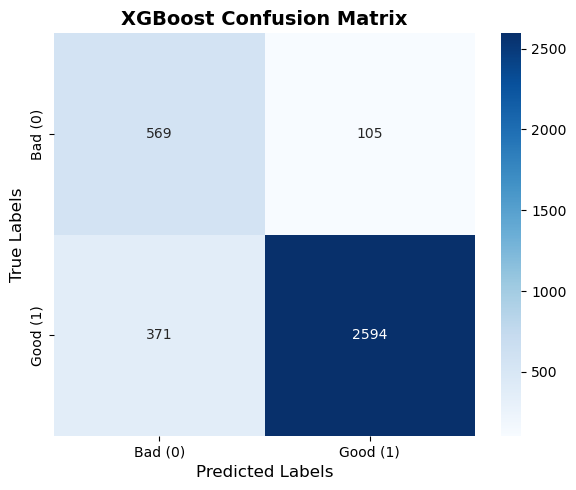

In [82]:
import gradio as gr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -------------------------------------------------------------
# GENERATE THE CONFUSION MATRIX
# -------------------------------------------------------------
# Compute the raw confusion matrix values
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad (0)", "Good (1)"],
    yticklabels=["Bad (0)", "Good (1)"],
)
plt.title("XGBoost Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd

# Pass the model first, then the file path destination
joblib.dump(xgb, '../models/xgb.joblib')
print('Saved Successfully')

Saved Successfully


In [84]:
# -------------------------------------------------------------
# 2. DEFINE GRADIO PREDICTION FUNCTION
# -------------------------------------------------------------
def predict_loan_status(
    loanamount_x,
    totaldue_x,
    termdays_x,
    longitude_gps,
    latitude_gps,
    loanamount_y,
    totaldue_y,
    termdays_y,
    age,
    first_payment_delay_days,
    prev_actual_days,
    is_weekend,
    daily_payment_burden,
    employment_status,
    bank_account_type,
    bank_name_encoded,
):
    # Construct a dictionary holding all 21 raw model variables
    input_data = {
        "loanamount_x": float(loanamount_x),
        "totaldue_x": float(totaldue_x),
        "termdays_x": int(termdays_x),
        "longitude_gps": float(longitude_gps),
        "latitude_gps": float(latitude_gps),
        "loanamount_y": float(loanamount_y),
        "totaldue_y": float(totaldue_y),
        "termdays_y": float(termdays_y),
        "age": int(age),
        "first_payment_delay_days": int(first_payment_delay_days),
        "prev_actual_days": int(prev_actual_days),
        "is_weekend": int(1 if is_weekend == "Yes" else 0),
        "daily_payment_burden": float(daily_payment_burden),
        # Unpack the One-Hot employment status fields
        "employment_status_clients_Permanent": int(
            1 if employment_status == "Permanent" else 0
        ),
        "employment_status_clients_Retired": int(
            1 if employment_status == "Retired" else 0
        ),
        "employment_status_clients_Self-Employed": int(
            1 if employment_status == "Self-Employed" else 0
        ),
        "employment_status_clients_Student": int(
            1 if employment_status == "Student" else 0
        ),
        "employment_status_clients_Unemployed": int(
            1 if employment_status == "Unemployed" else 0
        ),
        # Unpack the One-Hot account type fields
        "bank_account_type_Other": int(1 if bank_account_type == "Other" else 0),
        "bank_account_type_Savings": int(
            1 if bank_account_type == "Savings" else 0
        ),
        "bank_name_encoded": float(bank_name_encoded),
    }

    # Turn the raw inputs into a single row DataFrame matching training order exactly
    input_df = pd.DataFrame([input_data])

    # Ensure column execution order matches X_train exactly to avoid feature mismatch errors
    input_df = input_df[X_train.columns]

    # Predict loan probabilities
    probabilities = xgb.predict_proba(input_df)[0]
    bad_prob, good_prob = probabilities[0], probabilities[1]

    # Structure user-facing display output string
    status = "🟢 GOOD LOAN (Low Risk)" if good_prob >= 0.5 else "🔴 BAD LOAN (High Risk)"
    result_text = f"**Prediction:** {status}\n\n* Confidence Good: {good_prob:.2%}\n* Confidence Bad: {bad_prob:.2%}"

    return result_text


# -------------------------------------------------------------
# 3. CREATE THE GRADIO UI LAYOUT
# -------------------------------------------------------------
with gr.Blocks(title="Credit Scoring Dashboard") as demo:
    gr.Markdown("# 🏦 Credit Risk Assessment & Scoring Portal")
    gr.Markdown(
        "Input client credit details below to instantly run assessment using the trained XGBoost Engine."
    )

    with gr.Row():
        # Column 1: Current Loan Request Metrics
        with gr.Column():
            gr.Markdown("### 📦 Current Loan Data")
            loanamount_x = gr.Number(label="Loan Amount Requested (x)", value=30000)
            totaldue_x = gr.Number(label="Total Due (x)", value=35000)
            termdays_x = gr.Slider(
                minimum=7, maximum=90, step=1, label="Term Days (x)", value=30
            )
            daily_payment_burden = gr.Number(label="Daily Payment Burden", value=1166.0)
            is_weekend = gr.Radio(["No", "Yes"], label="Is Weekend Request?", value="No")

        # Column 2: Historical Customer Metrics
        with gr.Column():
            gr.Markdown("### ⏳ Historical Metrics & Demographics")
            age = gr.Number(label="Client Age", value=32)
            first_payment_delay_days = gr.Number(
                label="First Payment Delay Days", value=0
            )
            prev_actual_days = gr.Number(label="Previous Actual Days Taken", value=14)
            loanamount_y = gr.Number(label="Last Historical Loan Amount (y)", value=20000)
            totaldue_y = gr.Number(label="Last Historical Total Due (y)", value=24500)
            termdays_y = gr.Number(label="Last Historical Term Days (y)", value=30)

        # Column 3: Demographics & Bank Settings
        with gr.Column():
            gr.Markdown("### 🔑 Categorical Features")
            employment_status = gr.Radio(
                ["Permanent", "Retired", "Self-Employed", "Student", "Unemployed"],
                label="Employment Status",
                value="Permanent",
            )
            bank_account_type = gr.Radio(
                ["Savings", "Other"], label="Bank Account Type", value="Savings"
            )
            bank_name_encoded = gr.Number(
                label="Bank Name Target Encoded Value", value=0.15
            )
            longitude_gps = gr.Number(label="GPS Longitude", value=3.379)
            latitude_gps = gr.Number(label="GPS Latitude", value=6.524)

    # Output panel & submission triggers
    submit_btn = gr.Button("Evaluate Application Risk", variant="primary")
    output_box = gr.Markdown(label="Risk Assessment Analysis Result")

    submit_btn.click(
        fn=predict_loan_status,
        inputs=[
            loanamount_x,
            totaldue_x,
            termdays_x,
            longitude_gps,
            latitude_gps,
            loanamount_y,
            totaldue_y,
            termdays_y,
            age,
            first_payment_delay_days,
            prev_actual_days,
            is_weekend,
            daily_payment_burden,
            employment_status,
            bank_account_type,
            bank_name_encoded,
        ],
        outputs=output_box,
    )

# Launch interface cell
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
